In [2]:
import numpy as np
import pandas as pd


In [3]:
df_positions_all = pd.read_csv("../data/datasets/TMQM_SPECTO/raw/tmQM_Xall.csv")
df_positions_block3 = pd.read_csv("../data/datasets/TMQM_SPECTO/raw/tmqm_uvvis_final_40k.csv")
df_spectograms_raw_files = pd.read_csv("../data/datasets/TMQM_SPECTO/raw/tmQMg_.csv")


# 1 Analysis of the block 3 molecules
- the csv with the positions of the molecues

In [4]:
df_positions_block3.columns

Index(['Unnamed: 0', 'num_atoms', 'atom_types', 'atom_coords', 'origin_ID',
       'q', 'S', 'Stoichiometry', 'MND', 'ID', 'CSD_code', 'Electronic_E',
       'Dispersion_E', 'Dipole_M', 'Metal_q', 'HL_Gap', 'HOMO_Energy',
       'LUMO_Energy', 'Polarizability', 'CSD_years', 'SMILES'],
      dtype='object')

In [5]:
df_positions_block3.head()

,Unnamed: 0,num_atoms,atom_types,atom_coords,origin_ID,q,S,Stoichiometry,MND,ID,...,Electronic_E,Dispersion_E,Dipole_M,Metal_q,HL_Gap,HOMO_Energy,LUMO_Energy,Polarizability,CSD_years,SMILES
0,1,85,"['Sc', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H',...","[['-0.39411509310417', '2.60383495960443', '11...",VUCVUN,1,0,C35H37B2N9OSc(1+),6,tmqm_000001,...,-2733.400152,-0.178124,6.3480,1.31709,0.13228,-0.30419,-0.17191,496.262887,2020-2024,Cc1ccc([B-]23c4cccc5[B-]6(c7ccc(C)cc7)n7cccn7-...
1,4,98,"['Sc', 'P', 'P', 'Si', 'Si', 'O', 'O', 'C', 'C...","[['8.63913982507149', '9.84575671852354', '7.9...",BEGZOG,0,0,C30H61O2P2ScSi2,5,tmqm_000004,...,-3351.869750,-0.189730,3.9232,1.24247,0.14353,-0.19727,-0.05374,496.266851,2020-2024,CC(C)(C)P1(Oc2cccc3OP(C(C)(C)C)(C(C)(C)C)->[Sc...
2,5,111,"['Sc', 'P', 'O', 'O', 'N', 'C', 'C', 'C', 'C',...","[['7.48599835927059', '6.9628737838508', '4.23...",JIXWUM,0,0,C44H61NO2PSSc,4,tmqm_000005,...,-3417.887273,-0.238249,5.1840,1.26057,0.13612,-0.19172,-0.05560,586.295408,2020-2024,CC(C)(C)c1cccc(C(C)(C)C)c1[O-]->[Sc+3]1(<-[O-]...
3,18,87,"['Sc', 'N', 'N', 'C', 'H', 'C', 'H', 'C', 'H',...","[['13.30342114437391', '4.5866810739603', '11....",NURLUK,-1,0,C38H46N2Sc(1-),4,tmqm_000018,...,-2345.249964,-0.177549,3.6761,1.07056,0.07313,-0.00492,0.06821,460.106465,2020-2024,Cc1cc(C)cc([N-](C(C)(C)C)->[Sc+]234(<-c5c6cccc...
4,30,74,"['Sc', 'N', 'C', 'H', 'H', 'C', 'C', 'H', 'H',...","[['3.81975527757415', '7.3767175172877', '0.23...",XIGZUM,0,0,C30H41N2Sc,9,tmqm_000030,...,-2037.450028,-0.147563,0.9732,1.23302,0.13479,-0.16459,-0.02980,373.254006,2020-2024,Cc12->[Sc+3]34567(<-[CH2-]c8ccccc8N->3(C)C)(<-...


In [6]:
# to chech if the CSD_code is same as origin_ID
df_positions_block3[df_positions_block3['CSD_code'] != df_positions_block3['origin_ID']] 


,Unnamed: 0,num_atoms,atom_types,atom_coords,origin_ID,q,S,Stoichiometry,MND,ID,...,Electronic_E,Dispersion_E,Dipole_M,Metal_q,HL_Gap,HOMO_Energy,LUMO_Energy,Polarizability,CSD_years,SMILES


In [7]:
# to check if the id is indeed unique 
df_positions_block3['CSD_code'].value_counts()[df_positions_block3['CSD_code'].value_counts() > 1]

Series([], Name: count, dtype: int64)

In [8]:
df_positions_block3['atom_types'][0]

"['Sc', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'C', 'C', 'H', 'C', 'H', 'C', 'C', 'H', 'C', 'H', 'C', 'H', 'H', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'C', 'H', 'B', 'B', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H']"

## 1.1 Analysis of the izomers (the same type and number of atoms)

In [ ]:
import ast
from collections import Counter
df_positions_block3['atom_types_list'] = df_positions_block3['atom_types'].apply(ast.literal_eval)
df_positions_block3['atom_counts'] = df_positions_block3['atom_types_list'].apply(lambda x: tuple(sorted(Counter(x).items())))
iso_groups = df_positions_block3.groupby('atom_counts')
duplicates = iso_groups.filter(lambda g: len(g) > 1)
duplicates[['CSD_code', 'atom_counts']]



,CSD_code,atom_counts
3,NURLUK,"((C, 38), (H, 46), (N, 2), (Sc, 1))"
12,NURLOE,"((C, 38), (H, 46), (N, 2), (Sc, 1))"
14,CUJXIR,"((C, 29), (F, 2), (H, 45), (N, 2), (O, 1), (Sc..."
25,JIXWEW,"((C, 48), (H, 65), (N, 3), (O, 2), (P, 1), (Sc..."
87,CUJXOX,"((C, 29), (F, 2), (H, 45), (N, 2), (O, 1), (Sc..."
...,...,...
40088,AFEDEV,"((C, 19), (Cl, 2), (H, 15), (N, 3), (Zn, 1))"
40091,IZAVEK,"((C, 26), (H, 18), (N, 4), (O, 9), (Zn, 1))"
40092,QIPXES,"((C, 16), (H, 20), (N, 6), (S, 2), (Zn, 1))"
40098,HEGCEC,"((C, 11), (Cl, 2), (H, 16), (N, 4), (Zn, 1))"


In [13]:
# counts of different izomers
duplicates['atom_counts'].value_counts()

atom_counts
((C, 44), (H, 28), (N, 4), (Zn, 1))                    58
((C, 25), (Co, 1), (H, 16), (N, 4), (O, 3))            22
((C, 24), (H, 32), (Mn, 1), (N, 4), (O, 4))            22
((C, 4), (Co, 1), (H, 16), (N, 6), (O, 4))             19
((C, 9), (H, 4), (Mn, 1), (O, 5))                      14
                                                       ..
((C, 26), (Cr, 1), (H, 16), (O, 3))                     2
((C, 13), (Cr, 1), (H, 13), (N, 1), (O, 5))             2
((C, 16), (Cr, 1), (H, 17), (N, 1), (O, 3))             2
((C, 25), (Cr, 1), (H, 24), (N, 1), (O, 3), (P, 1))     2
((C, 28), (Cr, 1), (H, 21), (O, 4), (P, 1))             2
Name: count, Length: 3283, dtype: int64

# 2. ANALYSIS OF THE ABSORPTION SPECTIGRAM DATASET

In [36]:
df_spectograms_raw_files.columns.tolist()

['id',
 'homo_lumo_gap_gasphase',
 'dipole_moment_gasphase',
 'metal_charge_gasphase',
 'lambda_1_gasphase',
 'f_1_gasphase',
 'lambda_2_gasphase',
 'f_2_gasphase',
 'lambda_3_gasphase',
 'f_3_gasphase',
 'lambda_4_gasphase',
 'f_4_gasphase',
 'lambda_5_gasphase',
 'f_5_gasphase',
 'lambda_6_gasphase',
 'f_6_gasphase',
 'lambda_7_gasphase',
 'f_7_gasphase',
 'lambda_8_gasphase',
 'f_8_gasphase',
 'lambda_9_gasphase',
 'f_9_gasphase',
 'lambda_10_gasphase',
 'f_10_gasphase',
 'lambda_11_gasphase',
 'f_11_gasphase',
 'lambda_12_gasphase',
 'f_12_gasphase',
 'lambda_13_gasphase',
 'f_13_gasphase',
 'lambda_14_gasphase',
 'f_14_gasphase',
 'lambda_15_gasphase',
 'f_15_gasphase',
 'lambda_16_gasphase',
 'f_16_gasphase',
 'lambda_17_gasphase',
 'f_17_gasphase',
 'lambda_18_gasphase',
 'f_18_gasphase',
 'lambda_19_gasphase',
 'f_19_gasphase',
 'lambda_20_gasphase',
 'f_20_gasphase',
 'lambda_21_gasphase',
 'f_21_gasphase',
 'lambda_22_gasphase',
 'f_22_gasphase',
 'lambda_23_gasphase',
 'f_23

In [14]:
df_spectograms_raw_files['id'].isna().sum()

np.int64(0)

In [15]:
# selecting "id", "lambda" and "f" columns for the range form 1 to 30 
columns_to_filters = ['id']
for i in range(1, 31):
    columns_to_filters.extend([f'lambda_{i}_gasphase', f'f_{i}_gasphase'])
columns_to_filters

['id',
 'lambda_1_gasphase',
 'f_1_gasphase',
 'lambda_2_gasphase',
 'f_2_gasphase',
 'lambda_3_gasphase',
 'f_3_gasphase',
 'lambda_4_gasphase',
 'f_4_gasphase',
 'lambda_5_gasphase',
 'f_5_gasphase',
 'lambda_6_gasphase',
 'f_6_gasphase',
 'lambda_7_gasphase',
 'f_7_gasphase',
 'lambda_8_gasphase',
 'f_8_gasphase',
 'lambda_9_gasphase',
 'f_9_gasphase',
 'lambda_10_gasphase',
 'f_10_gasphase',
 'lambda_11_gasphase',
 'f_11_gasphase',
 'lambda_12_gasphase',
 'f_12_gasphase',
 'lambda_13_gasphase',
 'f_13_gasphase',
 'lambda_14_gasphase',
 'f_14_gasphase',
 'lambda_15_gasphase',
 'f_15_gasphase',
 'lambda_16_gasphase',
 'f_16_gasphase',
 'lambda_17_gasphase',
 'f_17_gasphase',
 'lambda_18_gasphase',
 'f_18_gasphase',
 'lambda_19_gasphase',
 'f_19_gasphase',
 'lambda_20_gasphase',
 'f_20_gasphase',
 'lambda_21_gasphase',
 'f_21_gasphase',
 'lambda_22_gasphase',
 'f_22_gasphase',
 'lambda_23_gasphase',
 'f_23_gasphase',
 'lambda_24_gasphase',
 'f_24_gasphase',
 'lambda_25_gasphase',
 'f_

In [16]:
df_specto_filters = df_spectograms_raw_files[columns_to_filters]
df_specto_filters.head()

,id,lambda_1_gasphase,f_1_gasphase,lambda_2_gasphase,f_2_gasphase,lambda_3_gasphase,f_3_gasphase,lambda_4_gasphase,f_4_gasphase,lambda_5_gasphase,...,lambda_26_gasphase,f_26_gasphase,lambda_27_gasphase,f_27_gasphase,lambda_28_gasphase,f_28_gasphase,lambda_29_gasphase,f_29_gasphase,lambda_30_gasphase,f_30_gasphase
0,ABACAL,306.80,0.0028,285.19,0.1514,273.68,0.0016,257.50,0.2278,251.04,...,172.49,0.0001,170.91,0.0094,168.72,0.0008,166.68,0.0473,165.62,0.0010
1,ABAFOZ,590.04,0.0061,510.00,0.0047,431.49,0.0438,393.29,0.0008,383.43,...,225.59,0.0376,221.01,0.0160,220.96,0.0245,218.88,0.0116,218.83,0.0233
2,ABAFUF,479.51,0.0004,467.45,0.0013,446.84,0.0002,434.53,0.0003,329.84,...,190.78,0.0498,188.37,0.2066,187.65,0.0106,186.68,0.0564,185.04,0.0397
3,ABAGAM,469.85,0.0020,461.48,0.0018,448.34,0.0004,431.19,0.0004,366.40,...,231.18,0.6863,230.17,0.5575,229.53,0.1138,225.40,0.0091,222.57,0.6429
4,ABAJAP,2043.02,0.0020,1235.22,0.0015,680.09,0.0015,574.89,0.0002,408.77,...,229.32,0.0109,227.92,0.0264,225.89,0.0010,222.89,0.0009,222.07,0.0120


In [17]:
# how many izomers have the calulated spectogram
duplicates['CSD_code'].isin(df_specto_filters['id']).value_counts()

CSD_code
True     5245
False    2696
Name: count, dtype: int64

In [18]:
# selecing only those spectograms that belong to the selected block 3 (so the ones belonging to the tmqm_uvvis_final_40k.csv)
df_specto_block_3 = df_specto_filters[df_specto_filters['id'].isin(df_positions_block3['CSD_code'])]
len(df_specto_block_3)

25898

So we have around 26k od spectoggrams 

In [43]:
df_specto_block_3.to_csv("../data/datasets/TMQM_SPECTO/raw/tmqm_specto_block3.csv", index=False)

In [ ]:
# how many izomers we have in block 3
duplicates[duplicates['CSD_code'].isin(df_specto_block_3['id'])]['atom_counts'].value_counts()


atom_counts
((C, 20), (H, 22), (N, 2), (Ni, 1), (O, 4))     14
((C, 4), (Co, 1), (H, 16), (N, 6), (O, 4))      13
((B, 18), (C, 4), (Co, 1), (H, 22))              9
((C, 24), (H, 22), (N, 2), (Ni, 1), (O, 4))      8
((C, 24), (H, 20), (N, 10), (Ni, 1))             8
                                                ..
((C, 16), (H, 36), (Ni, 1), (P, 2), (S, 4))      1
((C, 18), (H, 24), (N, 10), (Ni, 1), (S, 2))     1
((Br, 2), (C, 18), (H, 32), (N, 4), (Ni, 1))     1
((C, 26), (H, 19), (N, 4), (O, 2), (Zn, 1))      1
((C, 31), (H, 46), (N, 2), (Zn, 1))              1
Name: count, Length: 2654, dtype: int64

# 3. Analysis of the `lambda_{i}_gasphase` and `f_{}_gasphase`
- How many moleucules have their 10 "lambdas" withing the "visible light" range (380nm - 750nm)
- How many "data points" (not whole molecules but single measurements) are withing the the "visible light" range

### 3.1 Rozkład lambdy 1

In [ ]:
# Sanity check- if for evry block the lambda_1 is bigger then lambda_2, lambda_2 bigger then lambda_3 etc
for i in range(1,30):
    bool_series = df_specto_block_3[f'lambda_{i}_gasphase'] < df_specto_block_3[f'lambda_{i+1}_gasphase']
    filterd_df = df_specto_block_3[bool_series]
    print(len(filterd_df))


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [23]:
df_specto_block_3['lambda_1_gasphase'].isna().sum()

np.int64(0)

In [24]:
# visible big outliers.
df_specto_block_3['lambda_1_gasphase'].describe()

count    25898.000000
mean       628.102283
std       1056.619763
min        154.890000
25%        348.000000
50%        446.130000
75%        620.147500
max      70350.940000
Name: lambda_1_gasphase, dtype: float64

In [27]:
MIN_LAMBDA_FOR_VISIVLE_LIGHT = 380
MAX_LAMBDA_FOR_VISIVLE_LIGHT = 750

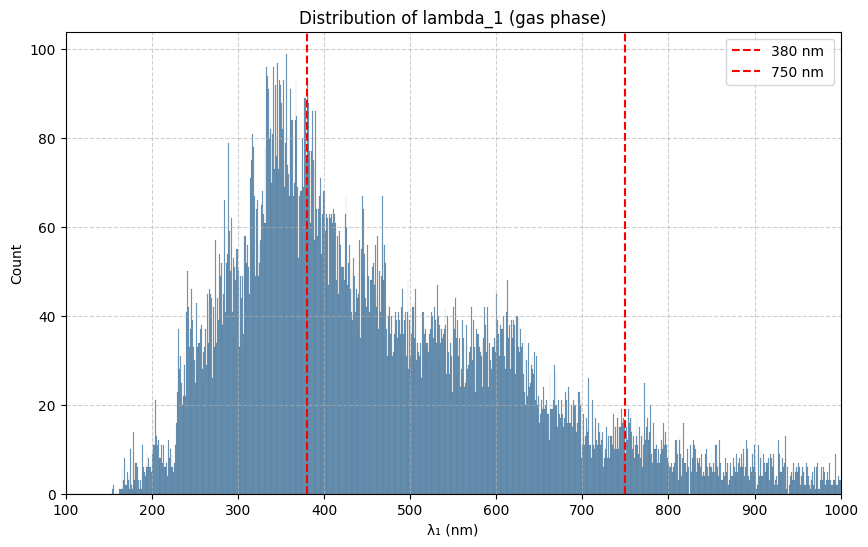

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(df_specto_block_3['lambda_1_gasphase'], bins=range(100, 1001), kde=False, color='steelblue')

plt.title('Distribution of lambda_1 (gas phase)')
plt.xlabel('λ₁ (nm)')
plt.ylabel('Count')
plt.xlim(100, 1000)
plt.grid(True, linestyle='--', alpha=0.6)

plt.axvline(MIN_LAMBDA_FOR_VISIVLE_LIGHT, color='red', linestyle='--', linewidth=1.5, label=f'{MIN_LAMBDA_FOR_VISIVLE_LIGHT} nm ')
plt.axvline(MAX_LAMBDA_FOR_VISIVLE_LIGHT, color='red', linestyle='--', linewidth=1.5, label=f'{MAX_LAMBDA_FOR_VISIVLE_LIGHT} nm ')

plt.legend()
plt.show()


We see that there is not a small numebr of moelules that have `lambda_1` smaller then 380nm. Since we checked that every `lambda_1 > lambda_i` for every `i` bigger than 1  then we now that those are the moelules that does not have any `lambda` withing the specified range.

In [29]:
specto_smallar_than_lower_bound = df_specto_block_3[df_specto_block_3['lambda_1_gasphase'] < MIN_LAMBDA_FOR_VISIVLE_LIGHT]
specto_bigger_than_upper_bound = df_specto_block_3[df_specto_block_3['lambda_1_gasphase'] > MAX_LAMBDA_FOR_VISIVLE_LIGHT]
specto_within_bounds = df_specto_block_3[
    (df_specto_block_3['lambda_1_gasphase'] >= MIN_LAMBDA_FOR_VISIVLE_LIGHT) &
    (df_specto_block_3['lambda_1_gasphase'] <= MAX_LAMBDA_FOR_VISIVLE_LIGHT)
]
print(
'\nTotal length of spectrograms:', len(df_specto_block_3),
'\nLength of spectrograms with lambda_1 < 380 nm:', len(specto_smallar_than_lower_bound),
'\nLength of spectrograms with lambda_1 > 750 nm:', len(specto_bigger_than_upper_bound),
'\nLength of spectrograms within 380-750 nm:', len(specto_within_bounds),
)


Total length of spectrograms: 25898 
Length of spectrograms with lambda_1 < 380 nm: 8996 
Length of spectrograms with lambda_1 > 750 nm: 3953 
Length of spectrograms within 380-750 nm: 12949


We will evaluate only the subset that makes sense for us so those molecules that have `lambda_1 >= 380` 

In [30]:
specto_bigger_than_lower_bound = df_specto_block_3[df_specto_block_3['lambda_1_gasphase'] >= MIN_LAMBDA_FOR_VISIVLE_LIGHT]
print(f'we select {len(specto_bigger_than_lower_bound)} out of {len(df_specto_block_3)}')

we select 16902 out of 25898


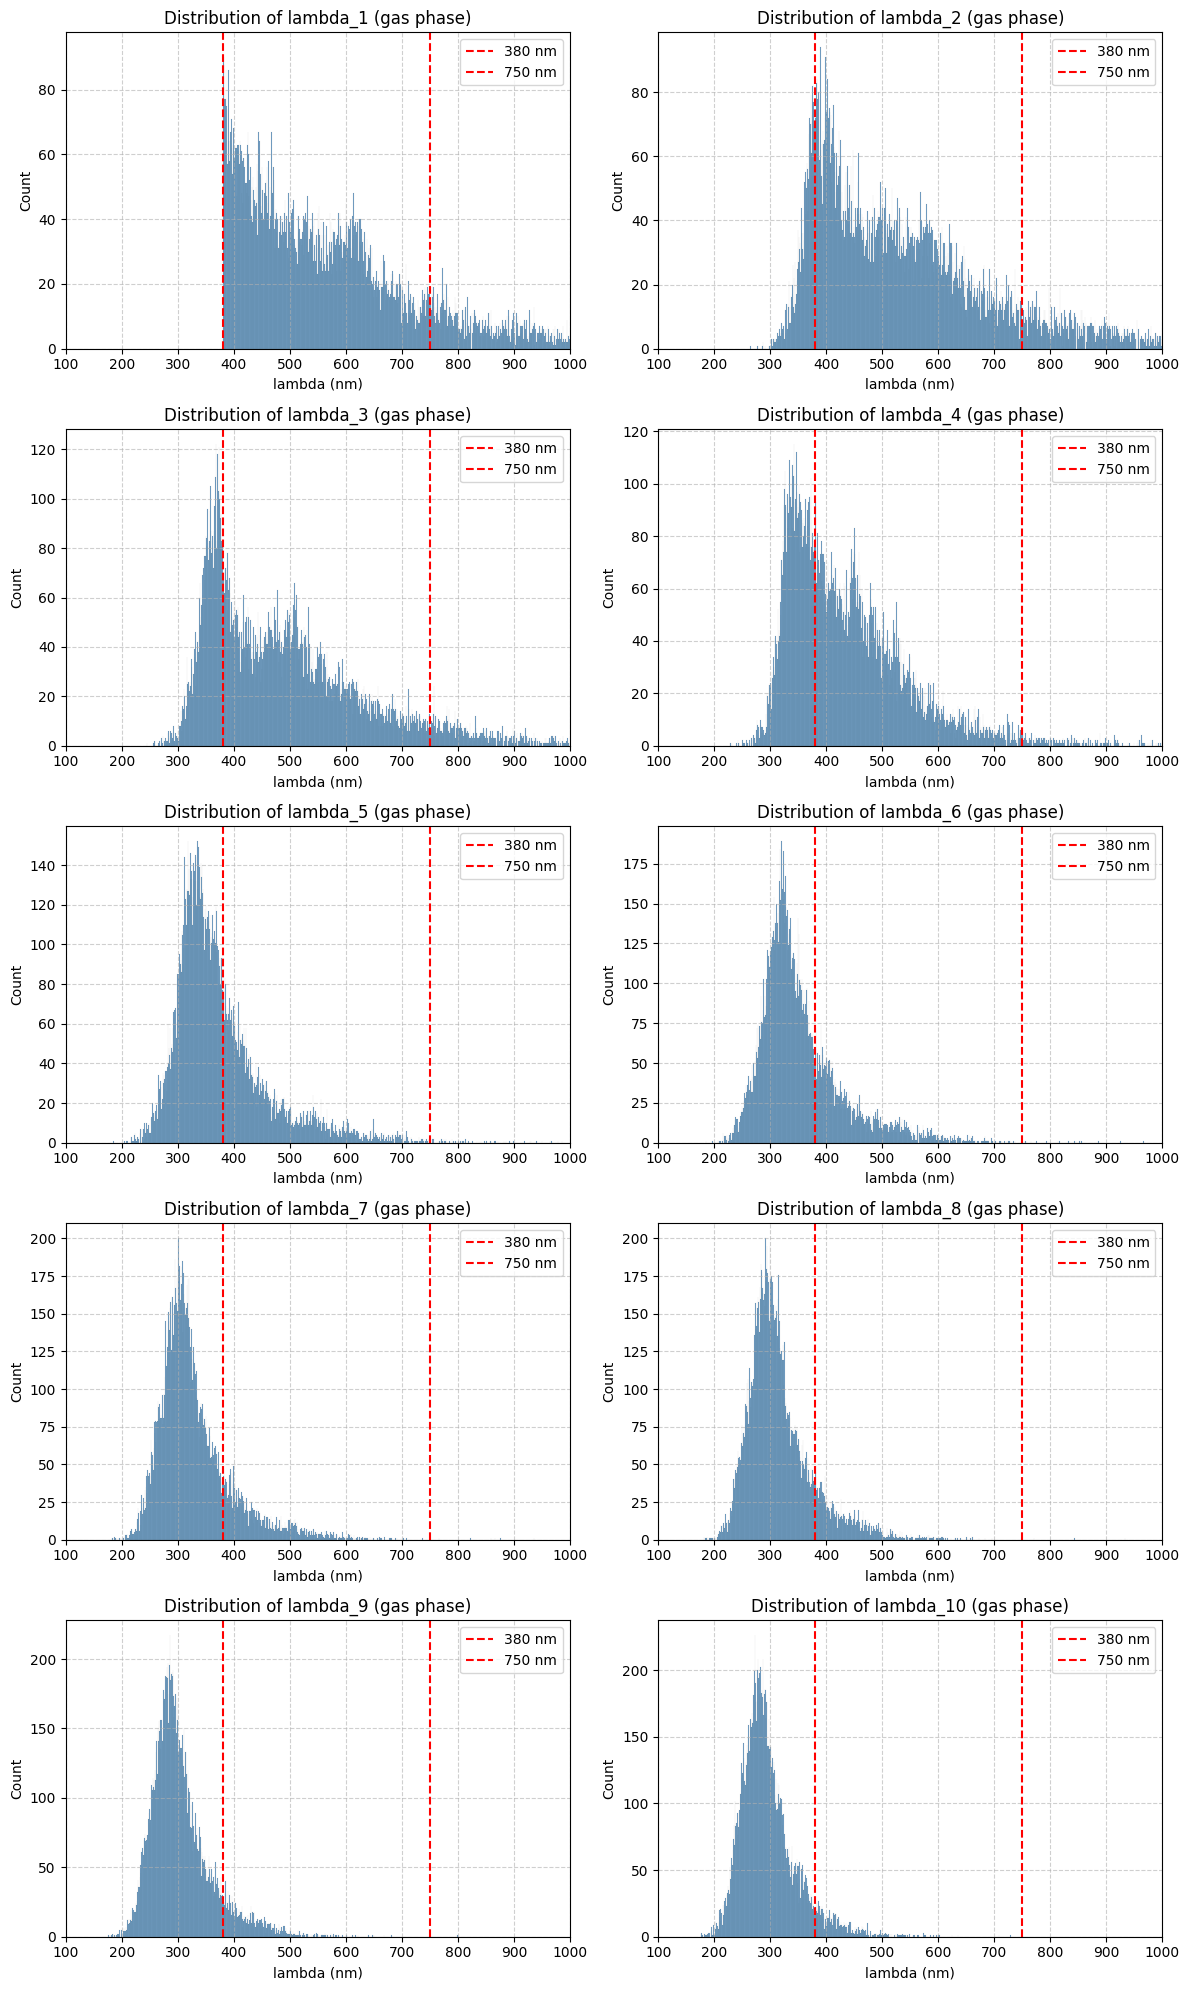

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create 2x5 grid of subplots
fig, axes = plt.subplots(5, 2, figsize=(12, 20))  # 5 rows, 2 columns
axes = axes.flatten()  # Flatten for easy iteration

for i in range(1, 11):
    ax = axes[i-1]

    sns.histplot(
        specto_bigger_than_lower_bound[f'lambda_{i}_gasphase'],
        bins=range(100, 1001),
        kde=False,
        color='steelblue',
        ax=ax
    )

    ax.set_title(f'Distribution of lambda_{i} (gas phase)')
    ax.set_xlabel('lambda (nm)')
    ax.set_ylabel('Count')
    ax.set_xlim(100, 1000)
    ax.grid(True, linestyle='--', alpha=0.6)

    ax.axvline(MIN_LAMBDA_FOR_VISIVLE_LIGHT, color='red', linestyle='--', linewidth=1.5, label=f'{MIN_LAMBDA_FOR_VISIVLE_LIGHT} nm')
    ax.axvline(MAX_LAMBDA_FOR_VISIVLE_LIGHT, color='red', linestyle='--', linewidth=1.5, label=f'{MAX_LAMBDA_FOR_VISIVLE_LIGHT} nm')
    ax.legend()

plt.tight_layout()
plt.show()


It is difficult to find 10 wavelengths within the visible light range, as each subsequent wavelength decreases in value, with the maximum around 300 nm.

In [37]:
# total 


def count_molecoules_within_range(df_to_test_original,range_val = 22, step = 9,  min_lambda = 380, max_lambda = 750):
    print(f'Range from {min_lambda} to {max_lambda}: ')
    df_to_test = df_to_test_original.copy()
    counter_correct = 0
    for i in range(1,range_val):
        lower_col = f'lambda_{i}_gasphase'
        upper_col = f'lambda_{i + step}_gasphase'

        lower_in_range = (df_to_test[lower_col] >= min_lambda) & (df_to_test[lower_col] <= max_lambda)
        upper_in_range = (df_to_test[upper_col] >= min_lambda) & (df_to_test[upper_col] <= max_lambda)

        correct_within_range = df_to_test[lower_in_range & upper_in_range]
        wrong_within_range = df_to_test[~(lower_in_range & upper_in_range)]


        print(
            f"For i={i}, we have {len(correct_within_range)} / {len(df_to_test)} molecules that have all lambda values (from lambda_{i} to lambda_{i+step}) in the specified range "
        )
        counter_correct += len(correct_within_range)
        df_to_test = wrong_within_range
    print(f'\nIn total we have {counter_correct} / {len(df_to_test_original)} molecules that have {step} lambdas in the range  from {min_lambda} to {max_lambda}')

count_molecoules_within_range(specto_bigger_than_lower_bound)


Range from 380 to 750: 
For i=1, we have 320 / 16902 molecules that have all lambda values (from lambda_1 to lambda_10) in the specified range 
For i=2, we have 131 / 16582 molecules that have all lambda values (from lambda_2 to lambda_11) in the specified range 
For i=3, we have 104 / 16451 molecules that have all lambda values (from lambda_3 to lambda_12) in the specified range 
For i=4, we have 89 / 16347 molecules that have all lambda values (from lambda_4 to lambda_13) in the specified range 
For i=5, we have 35 / 16258 molecules that have all lambda values (from lambda_5 to lambda_14) in the specified range 
For i=6, we have 19 / 16223 molecules that have all lambda values (from lambda_6 to lambda_15) in the specified range 
For i=7, we have 8 / 16204 molecules that have all lambda values (from lambda_7 to lambda_16) in the specified range 
For i=8, we have 0 / 16196 molecules that have all lambda values (from lambda_8 to lambda_17) in the specified range 
For i=9, we have 1 / 16

In [39]:
count_molecoules_within_range(specto_bigger_than_lower_bound, range_val = 27, step = 4)


Range from 380 to 750: 
For i=1, we have 3338 / 16902 molecules that have all lambda values (from lambda_1 to lambda_5) in the specified range 
For i=2, we have 626 / 13564 molecules that have all lambda values (from lambda_2 to lambda_6) in the specified range 
For i=3, we have 590 / 12938 molecules that have all lambda values (from lambda_3 to lambda_7) in the specified range 
For i=4, we have 389 / 12348 molecules that have all lambda values (from lambda_4 to lambda_8) in the specified range 
For i=5, we have 102 / 11959 molecules that have all lambda values (from lambda_5 to lambda_9) in the specified range 
For i=6, we have 35 / 11857 molecules that have all lambda values (from lambda_6 to lambda_10) in the specified range 
For i=7, we have 13 / 11822 molecules that have all lambda values (from lambda_7 to lambda_11) in the specified range 
For i=8, we have 2 / 11809 molecules that have all lambda values (from lambda_8 to lambda_12) in the specified range 
For i=9, we have 1 / 118

0 in range - 31
1 in range - 2369
2 in range - 2990
3 in range - 2635
4 in range - 3779
5 in range - 1570
6 in range - 1273
7 in range - 685
8 in range - 488
9 in range - 373
10 in range - 245
11 in range - 167
12 in range - 96
13 in range - 78
14 in range - 37
15 in range - 26
16 in range - 20
17 in range - 12
18 in range - 6
19 in range - 6
20 in range - 6
21 in range - 3
22 in range - 1
23 in range - 1
24 in range - 1
25 in range - 2
26 in range - 1
27 in range - 0
28 in range - 1
29 in range - 0
30 in range - 0
In total 16902 molecules


/tmp/ipykernel_7760/2704589401.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hist_df, x='count_in_range', y='num_samples', palette='viridis')


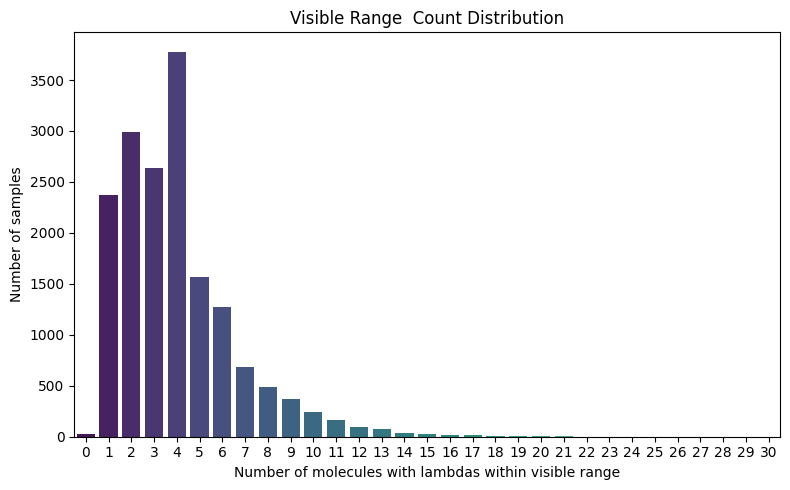

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_visible_lambda_counts(base_df, min_lambda = 380, max_lambda = 750, title="Visible Range λ Count Distribution"):
   
    cols = [f'lambda_{i}_gasphase' for i in range(1, 31)]
    in_range_mask = base_df[cols].ge(min_lambda) & base_df[cols].le(max_lambda)
    in_range_count = in_range_mask.sum(axis=1)
    hist = in_range_count.value_counts().reindex(range(0, 31), fill_value=0).sort_index()
    sum_val = 0
    for k, cnt in hist.items():
        print(f"{k} in range - {cnt}")
        sum_val+=cnt
    
    print(f'In total {sum_val} molecules')

    hist_df = pd.DataFrame({
        'count_in_range': hist.index,
        'num_samples': hist.values
    })

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(data=hist_df, x='count_in_range', y='num_samples', palette='viridis')
    plt.title(title)
    plt.xlabel("Number of molecules with lambdas within visible range")
    plt.ylabel("Number of samples")
    plt.xticks(range(0, 31))
    plt.tight_layout()
    plt.show()

plot_visible_lambda_counts(specto_bigger_than_lower_bound, title="Visible Range  Count Distribution")

In [ ]:
zero_oscillators = specto_bigger_than_lower_bound[
    (specto_bigger_than_lower_bound[[f'f_{i}_gasphase' for i in range(1, 11)]] == 0).any(axis=1)
]
len(zero_oscillators)


6994

In [ ]:
# detail infomation how many have one f_i = 0, how many have two f_i = 0, etc.
zero_oscillators_counts = {}
for i in range(1, 11):
    count = len(specto_bigger_than_lower_bound[
        (specto_bigger_than_lower_bound[[f'f_{j}_gasphase' for j in range(1, 11)]] == 0).sum(axis=1) == i
    ])
    zero_oscillators_counts[i] = count  
zero_oscillators_counts

{1: 3072,
 2: 1522,
 3: 692,
 4: 351,
 5: 185,
 6: 413,
 7: 570,
 8: 150,
 9: 36,
 10: 3}

In [49]:
sum(list(zero_oscillators_counts.values()))

6994